---
# <div style="text-align: center"> Introduction </div>
---

Along these tutorials, we will see how <span style="color:blue">**SCOPE**</span> interacts with the different parts of the code to handle the execution of computational workflows. 

These are the topics covered in each tutorial:
1) The **System** class and its sources: the **Specie**, **Cell** and **Atom** classes  
2) The Computational workflow: **Branch**, **Workflow**, **Job**, and **Computation** classes  
3) The **State** class  
4) The **Data**, **Collection** and **VNM** classes
5) The **Input_data** class, and **scope input files**
6) Running <span style="color:blue">**SCOPE**</span> - Part 1: File Structure
7) Running <span style="color:blue">**SCOPE**</span> - Part 2: Execution 
8) Running <span style="color:blue">**SCOPE**</span> - Part 3: Detailed Actions
9) The Azo add-on: Subclasses, Analysis and Creation of Azo Systems

---
# <div style="text-align: center"> Tutorial 1: Systems and their Sources</div>
---

In this tutorial, you will discover one of the main pillars of SCOPE: the **System**-class:

A **System** is way to organize collections of related chemical entities for later use in SCOPE. 

- A **Source** is one of those chemical entities. There are two main types of sources: the **Cell** and the **Specie**:
- A **Specie** is an isolated chemical specie. It has various subclasses: being **Molecule** and **Ligand** the most important  
- A **Cell** is a periodic structure. In essence, a Specie that includes cell parameters, but with different functionality. 

 
In the first part of this tutorial, we will open an existing **SYSTEM**, stored in a binary file, and navigate the hierarchy of chemical species that it contains.  
In the second part, we will create a new system from scratch, and feed it with **sources**

## Part 1. Navigate an existing SYSTEM

In [9]:
import os
import scope

In [10]:
## Path of the data folder. It should be "os.path.abspath('../')+'/Data/1-Tutorial_1/"
data_folder = os.path.abspath('../')+'/Data/1-Tutorial_1/'

## Loads the System object from a binary file, provided in the tutorial folder
sys = scope.load_binary(f"{data_folder}/Systems/ABITEM/ABITEM.npy")

## This will set the main path of the system to the data folder, overwriting and previous definition. 
## That way, any new file associated with this system created by SCOPE will be located in that folder.
sys.set_main_path(data_folder)

True

In [11]:
## All objects in SCOPE have a __repr__ method, so printing shows a summary of the object
print(sys)

-------------------------------------
-- >>> SCOPE System_sco Object >>> --
-------------------------------------
 Version               = 1.0
 Type                  = system
 Subtype               = sco_system
 Source Path           = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Sources/ABITEM/
 System File Path      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Systems/ABITEM/
 System File Name      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Systems/ABITEM/ABITEM.npy
 Computations Path     = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/1-Tutorial_1/Computations/ABITEM/

 Num Sources           = 6
     idx: type, name, formula               
     0: cell, ABITEM01, H104-C92-N24-O4-S8-Fe4 
     1: cell, ABITEM, H104-C92-N24-O4-S8-Fe4 
     2: cell, ref_hs_cell, H104-C92-N24-O4-S8-Fe4 
     3: cell, ref_ls_cell, H104-C92-N24-O4-S8-Fe4 
     4: specie, ref_hs_mol, H18-C20-N6-S2

The System is called ABITEM, and is associated with 6 **sources**:

```python
     0: cell, ABITEM01, H104-C92-N24-O4-S8-Fe4 
     1: cell, ABITEM, H104-C92-N24-O4-S8-Fe4 
     2: cell, ref_hs_cell, H104-C92-N24-O4-S8-Fe4 
     3: cell, ref_ls_cell, H104-C92-N24-O4-S8-Fe4 
     4: specie, ref_hs_mol, H18-C20-N6-S2-Fe 
     5: specie, ref_ls_mol, H18-C20-N6-S2-Fe 
```

Sources 0-1 are the **Cell** objects imported from the cell2mol interpretation of the .cif files  
Sources 2-3 are the **Cell** objects identified as reference HS and LS unit cells.  
Sources 4-5 are the **Specie** objects identified as reference HS and LS molecules.   

Below, we will navigate these sources to discover the Cell and Specie classes

### Sources 1: The CELL Class


In [12]:
# You can find sources by name, with the dedicated system-class function
found, cell = sys.find_source("ABITEM")
print('Found:', found)
# All objects in SCOPE can be printed, which displays their key information. 
print(cell)

Found: True
-----------------------------------
-- >>> SCOPE Cell_sco Object >>> --
-----------------------------------
 Version               = 1.0
 Type                  = cell
 SubType               = sco_cell
 Name                  = ABITEM
 Num Atoms             = 236
 Cell Parameters a:c   = [12.3008, 11.9241, 17.6916]
 Cell Parameters al:ga = [90.0, 92.704, 90.0]
 Volume (Angs^3)       = 2592.0433
 Number of Units (Z)   = 0
 Num Molecules:        = 8
 With Formulae:                               
    0: H18-C20-N6-S2-Fe 
    1: H18-C20-N6-S2-Fe 
    2: H8-C3-O 
    3: H8-C3-O 
    4: H8-C3-O 
    5: H8-C3-O 
    6: H18-C20-N6-S2-Fe 
    7: H18-C20-N6-S2-Fe 
-------------------------------
 Num of Ref Molecules: = 2
 With Formulae:                                  
    0: H18-C20-N6-S2-Fe 
    1: H8-C3-O 
 Phase                 = HS
 HS Molar Fraction     = 1.0




In [13]:
# Have a look at the CELL object above.

# -It has 236 atoms, whose coordinates are stored as cell.coord, and labels as cell.labels.
print("Labels and Coordinates:", cell.labels[0], cell.coord[0]) 
# -It has cell parameters, stored as cell.cell_param
print("Cell Parameters: (a,b,c,alpha,beta,gamma)", cell.cell_param)
# -It has 8 Molecules, stored inside cell.molecules
print("Number of Molecules:", len(cell.molecules))
# -It has 2 unique (i.e. types of) molecules, with formulae, and occurrence (how many times the molecule appears in the cell):
for mol in cell.ref_molecules:
    print("Unique Molecule Formula:", mol.formula, cell.get_occurrence(mol))
# -It has 4 stoichiometry units in the Cell (Z). That is, the stoichiometry is repeated Z times
print("Number of Stoichiometry Units (Z):", cell.z)

Labels and Coordinates: Fe [3.7430176, 3.9944543, 13.5094621]
Cell Parameters: (a,b,c,alpha,beta,gamma) [12.3008, 11.9241, 17.6916, 90.0, 92.704, 90.0]
Number of Molecules: 8
Unique Molecule Formula: H18-C20-N6-S2-Fe 0
Unique Molecule Formula: H8-C3-O 0
Number of Stoichiometry Units (Z): 0


In [14]:
# Apart from attributes, you can also run CELL-class functions.
# Here we try cell.check_fragmentation(), which checks if any molecule appears fragmented in the unit cell due to how the cell is cut
cell.check_fragmentation(debug=1)

CELL.CHECK_FRAGMENTATION: molecules available. Checking Fragmentation
CELL.CHECK_FRAGMENTATION: compared H18-C20-N6-S2-Fe and H18-C20-N6-S2-Fe without graph analysis: issame=True
CELL.CHECK_FRAGMENTATION: compared H18-C20-N6-S2-Fe and H8-C3-O without graph analysis: issame=False
CELL.CHECK_FRAGMENTATION: compared H18-C20-N6-S2-Fe and H18-C20-N6-S2-Fe without graph analysis: issame=True
CELL.CHECK_FRAGMENTATION: compared H18-C20-N6-S2-Fe and H8-C3-O without graph analysis: issame=False
CELL.CHECK_FRAGMENTATION: compared H8-C3-O and H18-C20-N6-S2-Fe without graph analysis: issame=False
CELL.CHECK_FRAGMENTATION: compared H8-C3-O and H8-C3-O without graph analysis: issame=True
CELL.CHECK_FRAGMENTATION: compared H8-C3-O and H18-C20-N6-S2-Fe without graph analysis: issame=False
CELL.CHECK_FRAGMENTATION: compared H8-C3-O and H8-C3-O without graph analysis: issame=True
CELL.CHECK_FRAGMENTATION: compared H8-C3-O and H18-C20-N6-S2-Fe without graph analysis: issame=False
CELL.CHECK_FRAGMENTATION:

False

In [15]:
# This CELL is a little bit special, though. It was created by the "Spin_Crossover" add-on included in SCOPE. 
# This add-on creates SCO_CELLs, which are subclasses of CELL, created to accomodate the specificities of this type of molecules.
# Notice the subtype
print(cell.object_type)
print(cell.object_subtype)

cell
sco_cell


In [16]:
# This CELL was created from cell2mol data, and is associated with a CIF file, whose information is stored in a Cif-class object: 
print(cell.cif)

---------------------------------------------------
                   SCOPE .Cif file                 
---------------------------------------------------
 Name                  = ABITEM.cif
 Path                  = /data/ucsscms/svela/4-Merged/ABITEM/Original/ABITEM.cif
 Symmetry Group        = P 21/c
 Symmetry Operations   = ['x,y,z', '-x,1/2+y,1/2-z', '-x,-y,-z', 'x,-1/2-y,-1/2+z']
 Diffraction Temp      = 240.0
 Authors               = ['Rong-Jia Wei', 'Jun Tao', 'Rong-Bin Huang', 'Lan-Sun Zheng']
 Year of Publication   = 2011
 Journal Name          = Inorg.Chem.
 Journal Volume        = 50
 Journal Page          = 8553
 Has Associated Cell   = YES



In [17]:
# You can view the unit cell with cell.view(), which opens a 3D viewer
cell.view(size='large')

### Sources 2: The SPECIE Class

In [18]:
# Hopefully, you can identify the 4 transition metal complexes (TMCs) and the 4 solvent molecules in the viewer above.
# In any case, you can access those molecules through the cell.molecules attribute. 
len(cell.molecules)

8

#### Molecule Sub-Class

In [19]:
# MOLECULE-class objects are a subclass of SPECIE, which more broadly refers to any chemical specie, including ligands in transition metal complexes
# Here, we take the first molecule in the unit cell as an example:
mol = cell.molecules[0]
# Again, the key information can be displayed by printing the object
print(mol)


-----------------------------------
------ SCOPE MOLECULE Object ------
-----------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule
 Number of Atoms       = 47
 Formula               = H18-C20-N6-S2-Fe
 Charge                = 0
 Spin (alpha - beta)   = 0
 Number of Parents     = 1
 Has Adjacency Matrix  = YES
 Has Bonds             = YES

 Num of Ligands        = 3
   Ligand 0: C-N-S with 3 atoms. Smiles: [N-]=C=S
   Ligand 1: H18-C18-N4 with 40 atoms. Smiles: [H]c1nc(C([H])([H])N(C([H])([H])c2nc([H])c([H])c([H])c2[H])C([H])([H])c2nc([H])c([H])c([H])c2[H])c([H])c([H])c1[H]
   Ligand 2: C-N-S with 3 atoms. Smiles: [N-]=C=S

 Num of Metals         = 1
   Metal 0: Fe with charge:2 and spin:0




In [20]:
# Notice the molecule is of type=SPECIE, and subtype=MOLECULE. As mentioned above, MOLECULE is a subclass of SPECIE. 
# Also, this molecule is a TMC, as shown by:
print(mol.iscomplex)
# SCOPE will flag a molecule as a TMC whenever it has any atom of the d- or f-blocks of the periodic table.
# Whenever this happens, it will automatically split the molecule into metals and ligands 

True


In [21]:
# Ligands can be accessed with the "ligands" attribute: 
print(len(mol.ligands), "ligands in this TMC")

3 ligands in this TMC


In [22]:
# Similarly, Metals can be accessed with the "metals" attribute:
print(len(mol.metals), "metal atom(s) in this TMC")
# Metals belong to the ATOM class, which we will soon discover

1 metal atom(s) in this TMC


In [23]:
## All species can be visualized with the .view() method:
mol.view()

##### Comparing Species

In [24]:
### Also, SPECIES can be compared using the == operator:
mol2 = cell.molecules[1]
print(mol == mol2)

## The comparison above checks the composition of the molecules, but not their structure.
## Thus, two conformers of the same molecule will be considered equal. 
## The comparison uses chemical composition, connectivity, and graph topology

True


In [25]:
import time
import numpy as np

## Here, you can compare all molecules in the unit cell.
for idx, m1 in enumerate(cell.molecules):
    for jdx, m2 in enumerate(cell.molecules):
        # If they are the same, their RMSD is also calculated.
        if m1 == m2 and jdx > idx: 
            tini = time.time()
            rmsd = m1.rmsd(m2)
            tend = time.time()
            elapsed = np.round(tend - tini,2)
            print(idx, jdx, m1.formula, m1 == m2, "RMSD:", rmsd, "in", elapsed, "seconds")
        #elif jdx > idx:                                        # un-comment if you want to visualize all comparisons
        #    print(idx, jdx, m1.formula, m1 == m2)

# The computation of the RMSD requires that molecules are re-aligned, and their atoms reordered...
# ... to achieve the best possible overlap. This is done internally by SCOPE by the function:
#  -- scope.other.overlap_molecules() -- 
# Once overlapped, the RMSD can be easily computed:

0 1 H18-C20-N6-S2-Fe True RMSD: 3.58 in 0.14 seconds
0 6 H18-C20-N6-S2-Fe True RMSD: 0.0001 in 0.02 seconds
0 7 H18-C20-N6-S2-Fe True RMSD: 2.2408 in 0.02 seconds
1 6 H18-C20-N6-S2-Fe True RMSD: 2.2408 in 0.02 seconds
1 7 H18-C20-N6-S2-Fe True RMSD: 0.0001 in 0.02 seconds
2 3 H8-C3-O True RMSD: 0.1841 in 0.0 seconds
2 4 H8-C3-O True RMSD: 0.1841 in 0.0 seconds
2 5 H8-C3-O True RMSD: 0.0 in 0.0 seconds
3 4 H8-C3-O True RMSD: 0.0 in 0.0 seconds
3 5 H8-C3-O True RMSD: 0.1841 in 0.0 seconds
4 5 H8-C3-O True RMSD: 0.1841 in 0.0 seconds
6 7 H18-C20-N6-S2-Fe True RMSD: 2.2408 in 0.02 seconds


In [26]:
## Notice that the RMSD comparison above reflects the symmetry of the molecular crystal.

## As you can see in the .cif file printed above, this Cell has P 21/c symmetry. 
print(cell.cif.sym_group)
## This symmetry group is associated with 4 symmetry operations.
print(cell.cif.sym_ops)


P 21/c
['x,y,z', '-x,1/2+y,1/2-z', '-x,-y,-z', 'x,-1/2-y,-1/2+z']


In [27]:
# Leaving the identity aside, there are three symmetry operations connecting the four molecules of each type in the unit cell. 
# As a result, there are three groups of RMSD values within the set of TMC: [0.0, 2.2 and 3.5]

# For the EtOH molecule, its higher internal symmetry overcomes the crystallographic symmetry during the overlap procedure,
# resulting in only two groups of RMSD values [0.0, 0.1841] 


In [28]:
## The same task (overlap + RMSD) can be performed with RDKIT.
## Below is a basic script to build the molecule objects from the coordinates
## And then do the RMSD computation, carried out by the rdMolAlign.GetBestRMS function. 

from rdkit import Chem
from rdkit.Chem import rdMolAlign

def build_rdkit_mol(atom_labels, coords):
    """
    atom_labels: list of strings, e.g. ['C', 'H', 'H', 'O']
    coords: np.array of shape (N_atoms, 3)
    """
    mol = Chem.RWMol()  # editable molecule
    # add atoms
    for label in atom_labels:
        atom = Chem.Atom(label)
        mol.AddAtom(atom)
    # create a conformer (3D structure)
    conf = Chem.Conformer(len(atom_labels))
    for i, (x, y, z) in enumerate(coords):
        conf.SetAtomPosition(i, Chem.rdGeometry.Point3D(x, y, z))
    mol.AddConformer(conf)
    return mol

## Againg, we compare all molecules in the unit cell.
for idx, m1 in enumerate(cell.molecules):
    for jdx, m2 in enumerate(cell.molecules):
        # If they are the same, their RMSD is also calculated.
        if m1 == m2 and jdx > idx: 
            a1 = build_rdkit_mol(m1.labels, m1.coord)
            a2 = build_rdkit_mol(m2.labels, m2.coord)
            tini = time.time()
            rmsd_rdkit = np.round(rdMolAlign.GetBestRMS(a1, a2),2)
            tend = time.time()
            elapsed = np.round(tend - tini,2)
            print(idx, jdx, m1.formula, m1 == m2, "RMSD:", rmsd_rdkit, "in", elapsed, "seconds")

0 1 H18-C20-N6-S2-Fe True RMSD: 2.97 in 2.43 seconds
0 6 H18-C20-N6-S2-Fe True RMSD: 3.46 in 2.39 seconds
0 7 H18-C20-N6-S2-Fe True RMSD: 4.17 in 2.23 seconds
1 6 H18-C20-N6-S2-Fe True RMSD: 3.95 in 2.22 seconds
1 7 H18-C20-N6-S2-Fe True RMSD: 3.39 in 2.27 seconds
2 3 H8-C3-O True RMSD: 0.18 in 0.37 seconds
2 4 H8-C3-O True RMSD: 0.18 in 0.32 seconds
2 5 H8-C3-O True RMSD: 0.0 in 0.32 seconds
3 4 H8-C3-O True RMSD: 0.0 in 0.32 seconds
3 5 H8-C3-O True RMSD: 0.18 in 0.33 seconds
4 5 H8-C3-O True RMSD: 0.18 in 0.33 seconds
6 7 H18-C20-N6-S2-Fe True RMSD: 3.22 in 2.11 seconds


In [29]:
## Notice that the evaluation of the RMSD takes 10 times that of SCOPE
## Also, the crystal symmetry, which was succesfully captured in the RMSD values of SCOPE, is not captured here for the TMC.
## Manual inspection reveals that this is because the overlap procedure in RDKIT failed to find the correct alignment, and thus overestimates the RMSD. 

#### Ligand Sub-Class

In [30]:
## Again, you can access the ligand objects through the "ligands" attribute
lig = mol.ligands[0]
print(lig)

-----------------------------------
------- SCOPE LIGAND Object -------
-----------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = ligand
 Number of Atoms       = 3
 Formula               = C-N-S
 Charge                = -1
 Spin (alpha - beta)   = 0
 SMILES                = [N-]=C=S
 Number of Parents     = 2
 Has Adjacency Matrix  = NO 
 Has Bonds             = YES
 Has RDKIT Object      = YES




In [33]:
## The LIGAND is also a subclass of SPECIE (object_type=specie, object_subtype=ligand). 
print(lig.object_type, lig.object_subtype)
## It has some useful functions too, e.g.:
print(lig.get_denticity())        ## This one retrieves the denticity of the ligand
print(lig.get_connected_metals()) ## This one retreives all metals to which this ligand is connected 

specie ligand
1
[-----------------------------------------------
------------- SCOPE METAL Object --------------
-----------------------------------------------
 Version                      = 1.0
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Fe
 Atomic Number                = 26
 Atom Charge                  = 2
 Spin (alpha - beta)          = 0
 Metal Adjacencies (madjnum)  = 6
 Regular Adjacencies (adjnum) = 6

]


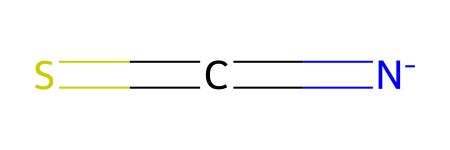

In [34]:
## As mentioned above, the Cell objects in this tutorial were imported from cell2mol CELL objects. 
## In these Cells, Ligands are associated with an rdkit object...
lig.rdkit_obj  

## As you can see, this object is imported and corrected: there were some issues with rdkit objects in cell2mol data, which are fixed during the import.

In [35]:
## ... and a Smiles
lig.smiles

'[N-]=C=S'

#### Metal Sub-Class

In [36]:
## Again, METAL is a subclass of ATOM (type=atom, subtype=metal)
## You can access the METAL object from the ligand with (1) lig.get_connected_metals(), as we've seen before, or (2) From the molecule: 
met = mol.metals[0]
print(met)

-----------------------------------------------
------------- SCOPE METAL Object --------------
-----------------------------------------------
 Version                      = 1.0
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Fe
 Atomic Number                = 26
 Atom Charge                  = 2
 Spin (alpha - beta)          = 0
 Metal Adjacencies (madjnum)  = 6
 Regular Adjacencies (adjnum) = 6




In [37]:
## Apart from attributes, it also has useful functions, e.g.:
print(met.get_coord_sphere())          ## These are the atoms that are coordinated to the metal

[------------------------------------------------
------------- SCOPE ATOM Object ----------------
------------------------------------------------
 Version                      = 1.0
 Type                         = atom
 Sub-Type                     = atom
 Label                        = N
 Atomic Number                = 7
 Atom Charge                  = 0
 Spin (alpha - beta)          = 0
 Metal Adjacencies (madjnum)  = 1
 Regular Adjacencies (adjnum) = 3

, ------------------------------------------------
------------- SCOPE ATOM Object ----------------
------------------------------------------------
 Version                      = 1.0
 Type                         = atom
 Sub-Type                     = atom
 Label                        = N
 Atomic Number                = 7
 Atom Charge                  = 0
 Spin (alpha - beta)          = 0
 Metal Adjacencies (madjnum)  = 1
 Regular Adjacencies (adjnum) = 3

, ------------------------------------------------
------------- SCOPE AT

In [38]:
print(met.get_coord_sphere_formula())  ## This is the formula of the atoms in the coordination sphere

N6


In [39]:
#met.get_cshm()   ## This one retrieves the Coordination Shape Measure of the metal.
                  ## The CShM quantifies how close the coordination environment is to an ideal geometry, which is an octahedron by default.
                  ## Unfortunately, the package that computes it (Cosymlib) introduces dependency issues during the installation of SCOPE 
                  ## Those dependencies, related to numpy, make the installation of Scope a challenge
                  ## We are currently waiting for an update of Cosymlib addressing those issues. 
                  ## In the meantime, if you're brave enough, you can try to install it manually

#### Going Upwards: Parents

In [40]:
## So far, we went down in the hierarchy: System -> Cell -> Molecule -> Metal/Ligand. You can also go back up:

# This retrieves the parent CELL object of the ligand
parent = lig.get_parent('cell') 
print(parent)

-------------------------------
   >>> SCOPE CELL Object >>>   
-------------------------------
 Version               = 1.0
 Type                  = cell
 SubType               = cell
 Name                  = ABITEM
 Num Atoms             = 236
 Cell Parameters a:c   = [12.3008, 11.9241, 17.6916]
 Cell Parameters al:ga = [90.0, 92.704, 90.0]
 Volume (Angs^3)       = 2592.0433
 Number of Units (Z)   = 0
 Num Molecules:        = 8
 With Formulae:                               
    0: H18-C20-N6-S2-Fe 
    1: H18-C20-N6-S2-Fe 
    2: H8-C3-O 
    3: H8-C3-O 
    4: H8-C3-O 
    5: H8-C3-O 
    6: H18-C20-N6-S2-Fe 
    7: H18-C20-N6-S2-Fe 
-------------------------------
 Num of Ref Molecules: = 2
 With Formulae:                                  
    0: H18-C20-N6-S2-Fe 
    1: H8-C3-O 




In [41]:
# And this retrieves the index of the ligand atoms in the parent molecule, so you can easily locate the child's atoms in parent attributes
idx = lig.get_parent_indices('molecule') 
print("Ligand Atom Indices in Parent's Molecule class:", idx)

for i, pi in enumerate(idx):
    lig_atom = lig.atoms[i]                                             ## i is the index in ligand atoms: 0,1,2 
    mol_atom = lig.get_parent('molecule').atoms[pi]                     ## pi is the index of the same atom in the parent molecule's atoms: 2,7,41
    print(i, pi, lig_atom.label, mol_atom.label, lig_atom == mol_atom)  ## Here, it compares both atoms. If TRUE, they are the same

Ligand Atom Indices in Parent's Molecule class: [2, 8, 42]
0 2 S S True
1 8 N N True
2 42 C C True


#### The Elephant in the Room: The ATOM Class

In [43]:
# As we've briefly seen above, species have atoms. 
len(mol.atoms)

47

In [46]:
## The first atom of the molecule happens to be the metal. The second is a regular atom. Notice the different subtype (metal vs. atom)
for at in mol.atoms[0:5]:                                  ## Printing the first 5 atoms
    print(at.get_parent_index('molecule'), at.label, at.object_subtype, at.charge, at.madjnum, at.adjnum)

## at.charge    is the formal atomic charge.
## at.madjnum   is the number of adjacencies the atom has with a metal center.
## at.adjnum    is the total number of adjacencies the atom has with any other atom

0 Fe metal 2 6 6
1 S atom 1 0 1
2 S atom 1 0 1
3 N atom 0 1 3
4 N atom 0 1 3


#### Charge and Spin

In [47]:
## Because cell2mol infers the charge of species in a unit cell, this info is also stored in the molecules:
for mol in cell.molecules:
    print(f"Formula: {mol.formula}, Charge: {mol.charge}, Spin: {mol.spin}")

Formula: H18-C20-N6-S2-Fe, Charge: 0, Spin: 0
Formula: H18-C20-N6-S2-Fe, Charge: 0, Spin: 0
Formula: H8-C3-O, Charge: 0, Spin: 0
Formula: H8-C3-O, Charge: 0, Spin: 0
Formula: H8-C3-O, Charge: 0, Spin: 0
Formula: H8-C3-O, Charge: 0, Spin: 0
Formula: H18-C20-N6-S2-Fe, Charge: 0, Spin: 0
Formula: H18-C20-N6-S2-Fe, Charge: 0, Spin: 0


In [48]:
## And also for the ligands and metals inside the molecules:
mol = cell.molecules[0]
for lig in mol.ligands:
    print(f"Ligand Formula: {lig.formula}, Charge: {lig.charge}, Spin: {lig.spin}")
for met in mol.metals:
    print(f"Metal: {met.label}, Charge: {met.charge}, Spin: {met.spin}")

Ligand Formula: C-N-S, Charge: -1, Spin: 0
Ligand Formula: H18-C18-N4, Charge: 0, Spin: 0
Ligand Formula: C-N-S, Charge: -1, Spin: 0
Metal: Fe, Charge: 2, Spin: 0


In [49]:
## All the way down to the ATOM objects, which are the actual bearers of spin and charge:
for at in mol.atoms:
    print(f"Atom: {at.label}, Charge: {at.charge}, Spin: {at.spin}")

Atom: Fe, Charge: 2, Spin: 0
Atom: S, Charge: 1, Spin: 0
Atom: S, Charge: 1, Spin: 0
Atom: N, Charge: 0, Spin: 0
Atom: N, Charge: 0, Spin: 0
Atom: N, Charge: 0, Spin: 0
Atom: N, Charge: 0, Spin: 0
Atom: N, Charge: -2, Spin: 0
Atom: N, Charge: -2, Spin: 0
Atom: C, Charge: 0, Spin: 0
Atom: H, Charge: 0, Spin: 0
Atom: C, Charge: 0, Spin: 0
Atom: H, Charge: 0, Spin: 0
Atom: C, Charge: 0, Spin: 0
Atom: H, Charge: 0, Spin: 0
Atom: C, Charge: 0, Spin: 0
Atom: H, Charge: 0, Spin: 0
Atom: C, Charge: 0, Spin: 0
Atom: C, Charge: 0, Spin: 0
Atom: H, Charge: 0, Spin: 0
Atom: H, Charge: 0, Spin: 0
Atom: C, Charge: 0, Spin: 0
Atom: H, Charge: 0, Spin: 0
Atom: C, Charge: 0, Spin: 0
Atom: H, Charge: 0, Spin: 0
Atom: C, Charge: 0, Spin: 0
Atom: C, Charge: 0, Spin: 0
Atom: H, Charge: 0, Spin: 0
Atom: H, Charge: 0, Spin: 0
Atom: C, Charge: 0, Spin: 0
Atom: H, Charge: 0, Spin: 0
Atom: C, Charge: 0, Spin: 0
Atom: H, Charge: 0, Spin: 0
Atom: C, Charge: 0, Spin: 0
Atom: H, Charge: 0, Spin: 0
Atom: C, Charge: 

In [50]:
## IMPORTANT: The charge and spin attribute for the SPECIE (molecules, ligands) and CELL classes are computed ...
## ... as the sum of the charge and spin of their constituent ATOM objects.mol.

## - If you want to modify an ATOM charge/spin, you can do it on the atom object (at) directly: 
##   - at.set_charge(1)
##   - at.set_spin(2)
##   - Alternatively, you can use spec.set_atomic_charges([list_of_charges]) ... 
##     ... and spec.set_atomic_spins([list_of_spins]) to set all atomic charges/spins of a SPECIE (spec) at once.

## Notice that, by "spin" we mean the total number of unpaired electrons (alpha - beta). 
## For instance, a spin of 1 means one unpaired electron (doublet).

## Here we take atom 0, which should be an Fe atom,
at = mol.atoms[0]

## We set it as a high-spin center, with 4 unpaired electrons (spin=4)
at.set_spin(4)

## When introducing the spin, the multiplicity and ms values are also stored as attributes:
print(f"Spin: {at.spin}, Ms: {at.ms}, Multiplicity: {at.multiplicity}")

## When Working with the STATE class in tutorial number 2, we will see how we can rapidly make changes to the charge and spin of specific atoms (typically metals) in the state. 

Spin: 4, Ms: 2.0, Multiplicity: 5


#### Bond Class

In [51]:
## Bonds are also stored as objects, with very limited functionality for now:
print(at.bonds)
## The formal bond order (bond.order) value above is extracted from the rdkit object, if available

[----------------------------------------------
------------- SCOPE BOND Object --------------
----------------------------------------------
 Version                 = 1.0
 Type                    = bond
 Atom1 Index in Molecule = 0
 Atom2 Index in Molecule = 8
 Label Atom1             = Fe
 Label Atom2             = N
 Formal Bond Order       = 0.5
 Distance                = 2.111 Angstrom

, ----------------------------------------------
------------- SCOPE BOND Object --------------
----------------------------------------------
 Version                 = 1.0
 Type                    = bond
 Atom1 Index in Molecule = 0
 Atom2 Index in Molecule = 3
 Label Atom1             = Fe
 Label Atom2             = N
 Formal Bond Order       = 0.5
 Distance                = 2.189 Angstrom

, ----------------------------------------------
------------- SCOPE BOND Object --------------
----------------------------------------------
 Version                 = 1.0
 Type                    = bond
 

---
## Part 2. Create a System
---

We will now create a simple system, that we will use later during Tutorial 7.

Systems only require a name, and are used mainly for organizational purposes: as we defined above:  
- A **System** is a collection of chemical entities with something in common, typically its chemical composition. The Main Purpose of this class is to store paths for later use in SCOPE, as well as its **sources**.

In [52]:
## Path of Tutorial 7's Data folder. Normally, it should be "os.path.abspath('.')+'/Data/Tutorial_7/". Change if necessary
tutorial_folder = os.path.abspath('../')+'/Data/7-Tutorial_7/'

In [53]:
## To create a system, you only need a name
test_sys   = scope.System("water")
print(test_sys)

---------------------------------
   >>> SCOPE System Object >>>   
---------------------------------
 Version               = 1.0
 Type                  = system
 Subtype               = system




In [54]:
## The created system is still 'empty'. That is, no sources are associated to it yet. 
## Before feeding it with sources, we will set the paths of the three relevant folders:
## - Sources         (test_sys.sources_path)
## - Computations    (test_sys.computations_path)
## - System          (test_sys.system_path)

In [55]:
## You can do it in 3 ways:

## (1) Directly as: 
test_sys.sources_path      = f"{tutorial_folder}Sources/water/"
test_sys.system_path       = f"{tutorial_folder}Systems/water/"
test_sys.system_file       = f"{tutorial_folder}Systems/water/water.npy"
test_sys.computations_path = f"{tutorial_folder}Computations/water/"

## (2) Reading from Environment-class object (uncomment to use). If you're working on a notebook, it might be more difficult to use:
# First, you load (or create) the enviroment.
#   env = load_binary(path) 
# Second:
#   self.set_paths_from_environment(env)

## (3) With self.set_paths(), and you just need to follow the instructions. If you're working on a notebook, it might be more difficult to use

In [56]:
## Once done, you can print the system to check that everything is correct
print(test_sys)

## You can check whether the paths are correct with the function below. It will also return TRUE/FALSE if folders exist: 
print(test_sys.check_paths(debug=1))


---------------------------------
   >>> SCOPE System Object >>>   
---------------------------------
 Version               = 1.0
 Type                  = system
 Subtype               = system
 Source Path           = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/7-Tutorial_7/Sources/water/
 System File Path      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/7-Tutorial_7/Systems/water/
 System File Name      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/7-Tutorial_7/Systems/water/water.npy
 Computations Path     = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/7-Tutorial_7/Computations/water/


True


In [57]:
## At this stage, WARNINGS might pop up because some folder might not exist if you used option (1) above. 
## Folders are automatically created with options (2) and (3). So don't worry for the moment

### Create a Molecule and Associate it to the System (i.e. Sourcing)

- Currently, sources can be imported from three formats:
    1) XYZ file
    2) RDKIT molecule object
    3) CELL2MOL cell -or molecule- object (information on cell2mol can be found in: 10.1038/s41524-022-00874-9)

Below, we will (1) create a molecule from an XYZ file, and source it to our "water" system.  
Also, we will explore the options of sourcing from either (2) an RDKIT molecule object, or (3) a cell2mol Cell object.

We will only keep (1) for our water system. (2) and (3) are only shown for completeness.

#### 1) Sourcing from an XYZ file

In [58]:
## Now we create an actual water molecule, whose geometry is read from an .xyz file
from scope.read_write     import read_xyz
from scope.classes_specie import Molecule

labels, coords = read_xyz(test_sys.sources_path+"geom1.xyz")
molec          = Molecule(labels, coords)
print(molec)

-----------------------------------
------ SCOPE MOLECULE Object ------
-----------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule
 Number of Atoms       = 3
 Formula               = H2-O
 Charge                = 0
 Spin (alpha - beta)   = 0
 Number of Parents     = 0
 Has Adjacency Matrix  = NO 
 Has Bonds             = NO




#### 2) Sourcing from an RDKIT molecule

In [59]:
## If we were to source an rdkit molecule object, we would do the following: 
from rdkit import Chem

rdkit_mol       = Chem.MolFromSmiles('c1ccccc1')                        ## As an example, we create benzene as an rdkit molecule.
imported_mol    = scope.classes_specie.import_molecule(rdkit_mol)       ## Imports it as a SCOPE molecule
imported_mol.set_bonds()                                                ## Created Bond objects using the Lewis structure in the rdkit mol
print(imported_mol)

## The function scope.classes_specie.import_molecule() is used to import molecule objects from any other supported package. Also from previous versions of SCOPE.
## Basically, as long as compatibility is possible, you will be able to update molecules from previous SCOPE versions using this function 

-----------------------------------
------ SCOPE MOLECULE Object ------
-----------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule
 Number of Atoms       = 12
 Formula               = H6-C6
 Charge                = 0
 Spin (alpha - beta)   = 0
 SMILES                = [H]c1c([H])c([H])c([H])c([H])c1[H]
 Number of Parents     = 0
 Has Adjacency Matrix  = YES
 Has Bonds             = YES
 Num of Ligands        = 0
 Num of Metals         = 0




In [60]:
# For instance, this is the first bond in which the first atom of the molecule is involved. An aromatic (formal bond order = 1.5) bond between C atoms in indices 0 and 1.  
print(imported_mol.atoms[0].bonds[0])

----------------------------------------------
------------- SCOPE BOND Object --------------
----------------------------------------------
 Version                 = 1.0
 Type                    = bond
 Atom1 Index in Molecule = 0
 Atom2 Index in Molecule = 1
 Label Atom1             = C
 Label Atom2             = C
 Formal Bond Order       = 1.5
 Distance                = 1.399 Angstrom




#### 3) Sourcing from cell2mol


In [61]:
## A CELL object is provided as part of this tutorials
cell2mol_cell = scope.load_binary(f"{sys.sources_path}Cell_ABITEM.gmol")

## Unfortunately, cell2mol objects do not (yet) have any print method to summarize their content. But you can see below the formulas of the molecules contained therein:
for cell2mol_mol in cell2mol_cell.moleclist:
    print(cell2mol_mol.formula)


H18-C20-N6-S2-Fe
H18-C20-N6-S2-Fe
H8-C3-O
H8-C3-O
H8-C3-O
H8-C3-O
H18-C20-N6-S2-Fe
H18-C20-N6-S2-Fe


In [62]:
## Similar to what we did before, the function scope.classes_cell.import_cell() is used to import cell objects from any other supported package (currently only cell2mol) ...
## ... or previous versions of SCOPE.
## Here we import the unit cell:
imported_cell = scope.classes_cell.import_cell(cell2mol_cell)
print(imported_cell)

-------------------------------
   >>> SCOPE CELL Object >>>   
-------------------------------
 Version               = 1.0
 Type                  = cell
 SubType               = cell
 Name                  = ABITEM
 Num Atoms             = 236
 Cell Parameters a:c   = [12.3008, 11.9241, 17.6916]
 Cell Parameters al:ga = [90.0, 92.704, 90.0]
 Volume (Angs^3)       = 2592.0433
 Number of Units (Z)   = 0
 Num Molecules:        = 8
 With Formulae:                               
    0: H18-C20-N6-S2-Fe 
    1: H18-C20-N6-S2-Fe 
    2: H8-C3-O 
    3: H8-C3-O 
    4: H8-C3-O 
    5: H8-C3-O 
    6: H18-C20-N6-S2-Fe 
    7: H18-C20-N6-S2-Fe 
-------------------------------
 Num of Ref Molecules: = 2
 With Formulae:                                  
    0: H18-C20-N6-S2-Fe 
    1: H8-C3-O 




In [63]:
## Here we import the one of the molecules in the unit cell:
imported_mol = scope.classes_specie.import_molecule(cell2mol_mol)
print(imported_mol)

-----------------------------------
------ SCOPE MOLECULE Object ------
-----------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule
 Number of Atoms       = 47
 Formula               = H18-C20-N6-S2-Fe
 Charge                = 0
 Spin (alpha - beta)   = 0
 Number of Parents     = 0
 Has Adjacency Matrix  = YES
 Has Bonds             = NO

 Num of Ligands        = 3
   Ligand 0: C-N-S with 3 atoms. Smiles: [N-]=C=S
   Ligand 1: H18-C18-N4 with 40 atoms. Smiles: [H]c1nc(C([H])([H])N(C([H])([H])c2nc([H])c([H])c([H])c2[H])C([H])([H])c2nc([H])c([H])c([H])c2[H])c([H])c([H])c1[H]
   Ligand 2: C-N-S with 3 atoms. Smiles: [N-]=C=S

 Num of Metals         = 1
   Metal 0: Fe with charge:2 and spin:0




#### Charge and Spin

In [64]:
## By default, molecules are neutral (and singlets) when created. 
## You can change it if needed:
molec.set_total_charge(-1)
## Notice that the charge has changed:
molec

-----------------------------------
------ SCOPE MOLECULE Object ------
-----------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule
 Number of Atoms       = 3
 Formula               = H2-O
 Charge                = -1
 Spin (alpha - beta)   = 0
 Number of Parents     = 0
 Has Adjacency Matrix  = NO 
 Has Bonds             = NO


In [65]:
## molec.set_total_charge() and molec.set_total_spin() are enough if you just want to specify charge and multiplicity for a quantum chemistry computation.
## These functions just assign the desired charge/spin to the first atom of the molecule
molec.atoms[0]

------------------------------------------------
------------- SCOPE ATOM Object ----------------
------------------------------------------------
 Version                      = 1.0
 Type                         = atom
 Sub-Type                     = atom
 Label                        = O
 Atomic Number                = 8
 Atom Charge                  = -1
 Spin (alpha - beta)          = 0
 No Metal Adjacency Info
 No Adjacency Info


In [66]:
## In this case, the first atom happens to be an Oxigen, so the -1 charge is plausible. 
## If it were a Hydrogen, it would be strange to have a -1 charge on it. 

## So it is much better if you individually select the atom you want to put the charge in, like:
molec.reset_charge()
molec.atoms[0].set_charge(-1)
molec

## Notice that we reset the charge, and added the -1 charge to the O atom directly
## SPECIE and CELL charges/spins are always computed as the sum of atomic charges/spins hosted in its ATOMS.
## This means that, if you change an ATOM charge/spin, you're automatically changing the charge of the parent class 

-----------------------------------
------ SCOPE MOLECULE Object ------
-----------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule
 Number of Atoms       = 3
 Formula               = H2-O
 Charge                = -1
 Spin (alpha - beta)   = 0
 Number of Parents     = 0
 Has Adjacency Matrix  = NO 
 Has Bonds             = NO


In [67]:
## We reset the charge, since we're gonna use this molecule in Tutorial 7, and we don't want a -1 charge on a water molecule.
## Basically, because it is not compatible
print(molec.check_spin_charge_compatibility())
## So we reset once again
molec.reset_charge()

False


In [68]:
## For SPIN, it works very similarly: 
molec.set_spin_metals(2, debug=1)

## Logically, it won't find any metal atom in a water molecule, so it will complain, but this is something that should work in a TMC
## Most functions have a debug variable as input, with 1 'being verbose', and 0 being 'quiet'. 

MOLECULE.SET_SPIN_METALS: there are no metals in this molecule


In [69]:
## Fortunately, we still have one of ABITEM's molecules in memory ("mol"). Here it should work
mol.set_spin_metals(2, debug=1)  ## 'mol' is one of ABITEM's molecules

MOLECULE.SET_SPIN_METALS: Preparing Spin Configuration for Specie H18-C20-N6-S2-Fe
MOLECULE.SET_SPIN_METALS: Received spins=[2]
MOLECULE.SET_SPIN_METALS: Setting spin=2 to metal atom Fe


2

#### Initial State (States are explained in Tutorial 3)

In [70]:
## Now we Create a State with the initial information, from which we will draw the starting data for the computations.
## The name "initial" is not mandatory. 
ini_state = molec.add_state("initial")    ## Here, the state is created, added to molecule, and returned as an object for further use.
## As we mention in Tutorial 3, "initial" states (whatever the name) are not created automatically.

## SPECIE sources only require geometry: 
ini_state.set_geometry(labels, coords)

## CELL sources would also require the cell_vectors and/or cell_parameters, which we don't have here:
#ini_state.set_cell() 

### Add Molecule as Source, and Save the system

In [71]:
## And source it to our system, giving it the name "geom1"
_ = test_sys.add_source('geom1',molec)
## Notice that the molecule has been added in the list of sources:
print(test_sys)

---------------------------------
   >>> SCOPE System Object >>>   
---------------------------------
 Version               = 1.0
 Type                  = system
 Subtype               = system
 Source Path           = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/7-Tutorial_7/Sources/water/
 System File Path      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/7-Tutorial_7/Systems/water/
 System File Name      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/7-Tutorial_7/Systems/water/water.npy
 Computations Path     = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/7-Tutorial_7/Computations/water/

 Num Sources           = 1
     idx: type, name, formula               
     0: specie, geom1, H2-O 




In [72]:
## Trying to add new molecules with the same name won't work, to avoid duplicities
_ = test_sys.add_source('geom1',molec, debug=1)

SYSTEM.FIND_SOURCE. Searching for source with geom1 in system with 1 sources:
    geom1 specie
SYSTEM.ADD_SOURCE: Source with name 'geom1' already exists in system 'water'
SYSTEM.ADD_SOURCE: If you would like to Overwrite, specify overwrite=True


In [73]:
## Finally, save the system to a file. By default, it will use the path stored in "test_sys.system_file"
test_sys.save()